In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\lbrice1\\Documents\\GitHub Repos\\ai_cheme_examples'

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [38]:
data = pd.read_excel('data/2.0-zw-Pyrolysis_Data_4-15_Reduced.xlsx')

data.head()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,2016-02-08 00:01:00,52285.872450,8547.494766,8978.327424,9357.470901,8957.223865,7775.966322,8560.723802,4393.776603,4402.800896,...,625.470850,624.958202,838.087231,838.164859,838.051705,839.634989,839.173723,835.603783,1015.874004,838.172544
1,2016-02-08 00:16:00,52366.836130,8579.277205,8972.173145,9362.073269,8980.865142,7794.664685,8544.727866,4411.197294,4378.762040,...,625.408625,624.906378,837.440458,840.343755,838.190985,836.150868,838.873225,841.042800,1013.053608,838.678272
2,2016-02-08 00:31:00,52275.680685,8551.972418,9003.021754,9321.712653,8943.094273,7806.982089,8557.347951,4405.819682,4406.877718,...,625.305447,624.575994,837.271119,836.131138,837.985024,840.251943,839.809701,840.314453,1015.694290,838.619070
3,2016-02-08 00:41:00,52384.019953,8547.920127,8991.534062,9326.887823,8963.589735,7811.920025,8598.247872,4402.730208,4391.711508,...,625.236662,624.355739,837.904604,839.058344,837.068393,838.029430,839.609082,837.038558,1016.267551,838.136643
4,2016-02-08 00:56:00,52313.273068,8530.787725,8990.634637,9335.973327,8958.809428,7772.523976,8576.032560,4406.699135,4401.453115,...,625.133484,624.025355,837.803211,837.767467,838.069275,840.034307,837.580220,838.166467,1013.241861,838.199481


In [76]:
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_data(X, y, x_name, y_name, time = None):

    fig = plt.figure(figsize=(10, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    #for col in data.iloc[:, 1:].columns:
    if time is not None:
        norm = TwoSlopeNorm(vmin=min(time), vcenter=np.mean(time), vmax=max(time))
        colors = [plt.cm.plasma(norm(c)) for c in time]

    axs0.scatter(X, y, color = colors, marker = 's', edgecolors='k', linewidth=1)


    axs0.set_xlabel(f'{x_name}', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(f'{y_name}', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    cbaxes = inset_axes(axs0, width="30%", height="3%", loc='upper left')

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.plasma), cax=cbaxes, shrink = 0.7, aspect = 30, orientation = 'horizontal')#, pad = 1)
    #plt.colorbar(cax=cbaxes, ticks=[0.,1], orientation='horizontal')

    
    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Time$', fontsize = 'x-large')
    cb.ax.tick_params(size=0)
    cb.set_ticks([])

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

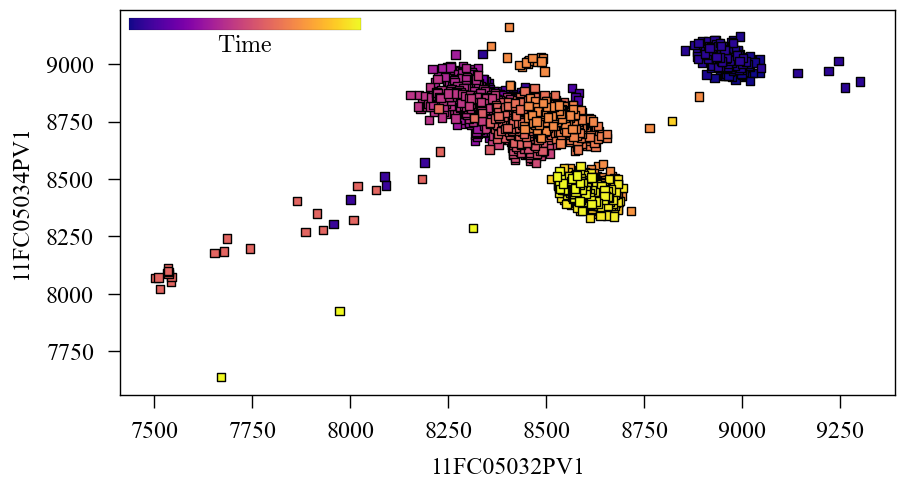

In [78]:
X = "11FC05032PV1"
y = "11FC05034PV1"

plot_data(data.iloc[:, data.columns.get_loc(X)], data.iloc[:, data.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data.iloc[:, 0]]))